# Disk Prior vs Volume Prior

Compare the distance prior assuming uniform density (volume prior, $p(d) \propto d^2$) with a Galactic disk prior that accounts for the exponential density profile.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

# import scienceplots  # noqa
# # plt.style.use('science')

from candel.model.mwcepheids import DiskPrior
from candel.model.utils import VolumePrior
from candel.pvdata.mwcepheids import load_data

## Prior setup

Define distance bounds and create both priors for a range of Galactic coordinates.

In [2]:
# Load R21 data with coordinates
data = load_data("../data/Riess2021_Table1_with_coords.csv")

# Select campaign: "C22", "C27", or None for all
campaign = "C22"

if campaign == "C22":
    mask = np.asarray(data.is_c22)
elif campaign == "C27":
    mask = np.asarray(data.is_c27)
else:
    mask = np.ones(data.n_stars, dtype=bool)

# Apply mask
names = data.names[mask]
ell = np.asarray(data.ell)[mask]
b = np.asarray(data.b)[mask]
n_stars = len(names)

print(f"Selected {n_stars} stars" + (f" ({campaign})" if campaign else ""))
print(f"ell range: [{ell.min():.1f}, {ell.max():.1f}] deg")
print(f"b range: [{b.min():.1f}, {b.max():.1f}] deg")

2026-02-07 13:27:18 Dropping 7 stars without EDR3 parallax: CY-AUR, DL-CAS, RW-CAM, SV-PER, SY-NOR, RX-CAM, U-AQL
2026-02-07 13:27:18 Loaded 67 stars from ../data/Riess2021_Table1_with_coords.csv
2026-02-07 13:27:18 Final sample: 67 stars (44 C22 + 23 C27)
Selected 44 stars (C22)
ell range: [12.1, 356.5] deg
b range: [-7.1, 5.9] deg


In [3]:
d_min, d_max = 0.1, 7  # kpc
d_grid = np.linspace(d_min, d_max, 500)

# Volume prior (same for all directions)
volume_prior = VolumePrior(d_min, d_max)
log_p_volume = volume_prior.log_prob(d_grid)
p_volume = np.exp(np.asarray(log_p_volume))

# Get parallax-based distance estimates: d ≈ 1/π [kpc]
pi_obs = np.asarray(data.pi_EDR3)[mask]  # parallax in mas
d_obs = 1.0 / pi_obs  # distance in kpc

# Select 20 example stars (evenly spaced)
n_examples = min(20, n_stars)
example_indices = np.linspace(0, n_stars - 1, n_examples, dtype=int)
example_names = [names[i] for i in example_indices]
example_ell = [ell[i] for i in example_indices]
example_b = [b[i] for i in example_indices]
example_d = [d_obs[i] for i in example_indices]

print(f"Showing {n_examples} example stars:")
for name, l, b_, d in zip(example_names, example_ell, example_b, example_d):
    print(f"  {name:12s}  ell={l:6.1f}°  b={b_:+6.1f}°  d≈{d:.2f} kpc")

Showing 20 example stars:
  AA-GEM        ell= 184.6°  b=  +2.7°  d≈3.22 kpc
  AQ-CAR        ell= 285.8°  b=  -3.3°  d≈2.77 kpc
  BK-AUR        ell= 159.0°  b=  +5.9°  d≈2.35 kpc
  CD-CYG        ell=  71.1°  b=  +1.4°  d≈2.54 kpc
  DD-CAS        ell= 116.8°  b=  +0.5°  d≈2.89 kpc
  GQ-ORI        ell= 199.8°  b=  -4.4°  d≈2.45 kpc
  KK-CEN        ell= 294.2°  b=  +2.7°  d≈6.58 kpc
  RW-CAS        ell= 129.0°  b=  -4.6°  d≈2.99 kpc
  RY-VEL        ell= 282.6°  b=  +1.5°  d≈2.66 kpc
  S-VUL         ell=  63.5°  b=  +0.8°  d≈4.22 kpc
  SV-VEL        ell= 286.0°  b=  +2.4°  d≈2.30 kpc
  SZ-CYG        ell=  84.4°  b=  +4.0°  d≈2.25 kpc
  UU-MUS        ell= 296.8°  b=  -3.2°  d≈3.27 kpc
  V-340-ARA     ell= 335.2°  b=  -3.8°  d≈4.18 kpc
  VX-PER        ell= 132.8°  b=  -3.0°  d≈2.55 kpc
  VZ-PUP        ell= 243.4°  b=  -3.3°  d≈4.55 kpc
  X-CYG         ell=  76.9°  b=  -4.3°  d≈1.10 kpc
  XX-CAR        ell= 291.3°  b=  -4.9°  d≈3.28 kpc
  XZ-CAR        ell= 290.3°  b=  -0.8°  d≈2.11 kpc
  Z-L

## Compare PDFs for selected stars

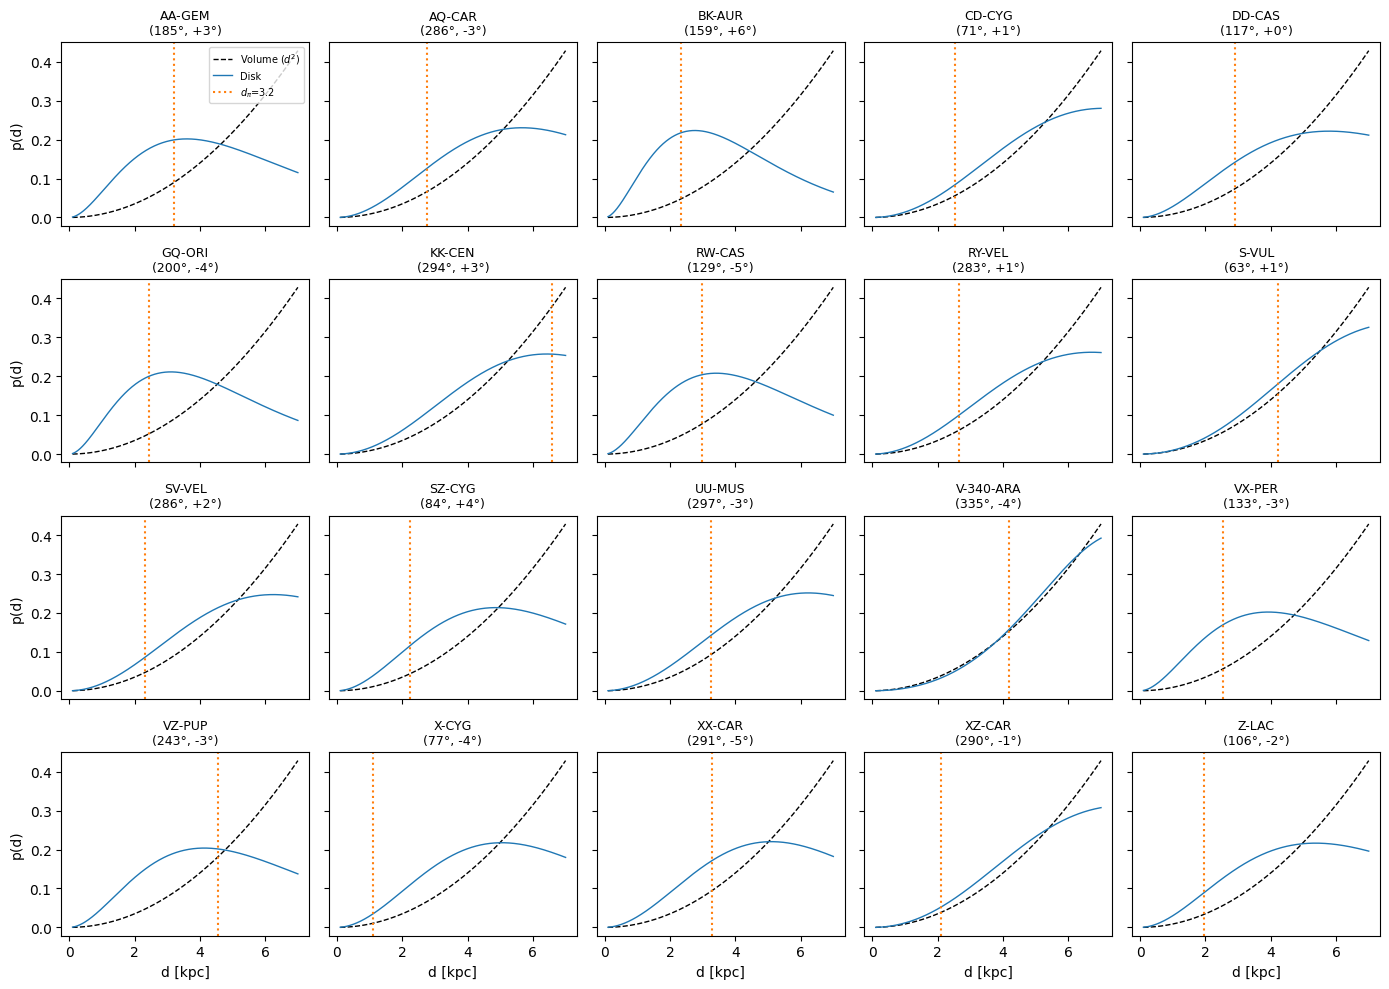

In [4]:
n_cols = 5
n_rows = (n_examples + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.5 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, (ax, name, el, bi, d_est) in enumerate(zip(axes, example_names, example_ell, example_b, example_d)):
    # Disk prior for this star
    disk_prior = DiskPrior(el, bi, d_min, d_max)
    log_p_disk = disk_prior.log_prob(d_grid)
    p_disk = np.exp(np.asarray(log_p_disk))
    
    ax.plot(d_grid, p_volume, 'k--', lw=1, label=r'Volume ($d^2$)')
    ax.plot(d_grid, p_disk, 'C0-', lw=1, label='Disk')
    
    # Mark estimated distance from parallax
    ax.axvline(d_est, color='C1', ls=':', lw=1.5, label=f'$d_\\pi$={d_est:.1f}')
    
    ax.set_title(f"{name}\n({el:.0f}°, {bi:+.0f}°)", fontsize=9)
    
    if i >= (n_rows - 1) * n_cols:
        ax.set_xlabel('d [kpc]')
    if i % n_cols == 0:
        ax.set_ylabel('p(d)')

# Hide unused subplots
for j in range(n_examples, len(axes)):
    axes[j].axis('off')
    
axes[0].legend(fontsize=7, loc='upper right')
fig.tight_layout()
fig.savefig(f"/Users/rstiskalek/Downloads/disk_prior_{campaign}.png", dpi=300)
plt.show()

## Effect of disk scale length

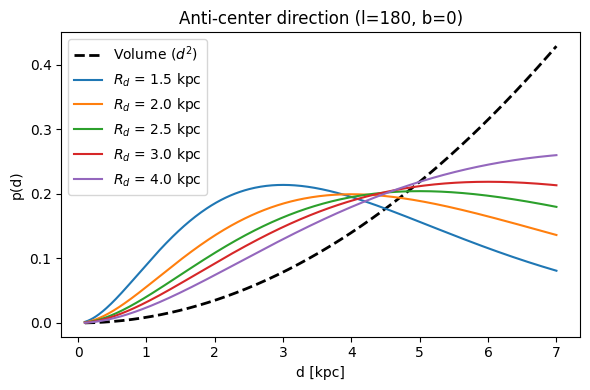

In [5]:
l, b = 180, 0  # Anti-center direction (most affected by disk falloff)

scale_lengths = [1.5, 2.0, 2.5, 3.0, 4.0]

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(d_grid, p_volume, 'k--', lw=2, label=r'Volume ($d^2$)')

for R_d in scale_lengths:
    disk_prior = DiskPrior(l, b, d_min, d_max, R_d=R_d)
    p_disk = np.exp(np.asarray(disk_prior.log_prob(d_grid)))
    ax.plot(d_grid, p_disk, lw=1.5, label=f'$R_d$ = {R_d} kpc')

ax.set_xlabel('d [kpc]')
ax.set_ylabel('p(d)')
ax.set_title(f'Anti-center direction (l={l}, b={b})')
ax.legend()
fig.tight_layout()
plt.show()

## Effect of disk scale height (latitude dependence)

In [ ]:
l = 90  # Perpendicular to GC direction
latitudes = [0, 10, 20, 30, 45]

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(d_grid, p_volume, 'k--', lw=2, label=r'Volume ($d^2$)')

for b in latitudes:
    disk_prior = DiskPrior(l, b, d_min, d_max, z_d=0.1)
    p_disk = np.exp(np.asarray(disk_prior.log_prob(d_grid)))
    ax.plot(d_grid, p_disk, lw=1.5, label=f'b = {b}°')

ax.set_xlabel('d [kpc]')
ax.set_ylabel('p(d)')
ax.set_title(f'l={l}°, varying latitude (z_d = 0.1 kpc)')
ax.legend()
fig.tight_layout()
plt.show()

## Compare expected distance for different directions

In [ ]:
# Grid of Galactic coordinates
l_arr = np.linspace(0, 360, 37)
b_arr = np.array([0, 15, 30, 45])

print(f"{'l':>6} {'b':>6} {'<d> volume':>12} {'<d> disk':>12} {'ratio':>8}")
print("-" * 50)

# Expected distance for volume prior
dd = d_grid[1] - d_grid[0]
d_mean_volume = np.sum(d_grid * p_volume) * dd

for b in b_arr:
    for l in l_arr[::4]:  # sample every 4th
        disk_prior = DiskPrior(l, b, d_min, d_max)
        p_disk = np.exp(np.asarray(disk_prior.log_prob(d_grid)))
        d_mean_disk = np.sum(d_grid * p_disk) * dd
        print(f"{l:>6.0f} {b:>6.0f} {d_mean_volume:>12.2f} {d_mean_disk:>12.2f} "
              f"{d_mean_disk/d_mean_volume:>8.2f}")

## All R21 Cepheids: disk vs volume prior

In [ ]:
# Use selected Cepheid coordinates
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(d_grid, p_volume, 'k--', lw=2, label=r'Volume ($d^2$)', zorder=10)

# Plot individual star priors
for i in range(n_stars):
    disk_prior = DiskPrior(ell[i], b[i], d_min, d_max)
    p_disk = np.exp(np.asarray(disk_prior.log_prob(d_grid)))
    ax.plot(d_grid, p_disk, lw=0.8, alpha=0.3, color='C0')

# Mean disk prior across all stars
disk_prior_all = DiskPrior(ell, b, d_min, d_max)
p_disk_all = np.exp(np.asarray(disk_prior_all.log_prob(d_grid[:, None])))
p_disk_mean = p_disk_all.mean(axis=1)
p_disk_mean /= np.trapezoid(p_disk_mean, d_grid)  # renormalize

ax.plot(d_grid, p_disk_mean, 'C0-', lw=2, label='Disk (mean over all stars)')

ax.set_xlabel('d [kpc]')
ax.set_ylabel('p(d)')
title = f'{n_stars} Cepheids'
if campaign:
    title += f' ({campaign})'
ax.set_title(f'{title}: individual priors (thin) vs mean (thick)')
ax.legend()
fig.tight_layout()
plt.show()